In [17]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
file = open('calls.csv')
df = pd.read_csv(file)
df

,timestamp,caller,callee,duration
0,184,300,301,121
1,3920,512,299,670
2,5623,301,300,504
3,9252,401,457,-1
4,15466,512,0,5
...,...,...,...,...
3595,2414934,706,401,78
3596,2415585,218,382,48
3597,2416059,561,631,13
3598,2416368,323,392,4


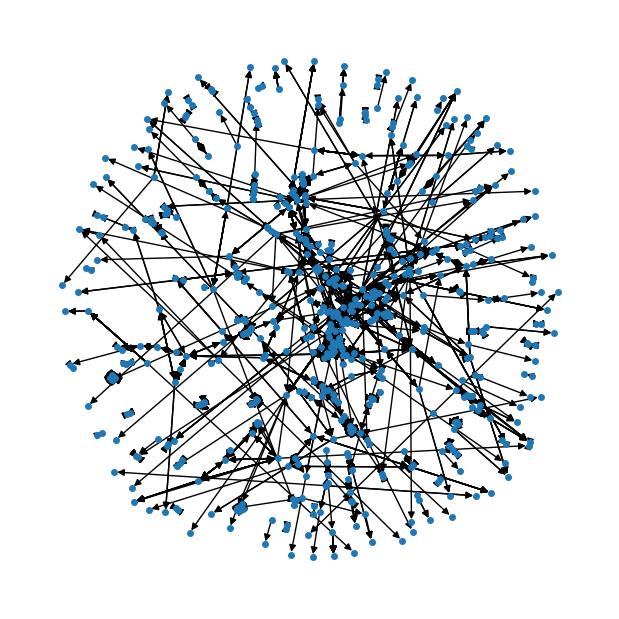

In [18]:
G = nx.from_pandas_edgelist(df, 'caller', 'callee', ['timestamp', 'duration'], create_using=nx.MultiDiGraph())
plt.figure(figsize=(6,6))
nx.draw(G, node_size=16)

In [19]:
'''network description'''
print(G)
print(f'Number of callers: {nx.number_of_nodes(G)}')
print(f'Number of calls: {nx.number_of_edges(G)}')
print(f'Graph is directed: {nx.is_directed(G)}')
print(f'Graph is weighted: {nx.is_weighted(G)}')
print(f'Graph is bipartite: {nx.is_bipartite(G)}')
print(f'Graph is acyclic: {nx.is_directed_acyclic_graph(G)}')
nx.is_multigraphical(G)

MultiDiGraph with 536 nodes and 3600 edges
Number of callers: 536
Number of calls: 3600
Graph is directed: True
Graph is weighted: False
Graph is bipartite: False
Graph is acyclic: False


False

In [20]:
# Aggregate calls between each pair (u, v)
G_agg = nx.DiGraph()
for u, v, data in G.edges(data=True):
    duration = data.get('duration', 0)
    if G_agg.has_edge(u, v):
        G_agg[u][v]['count'] += 1
        G_agg[u][v]['total_duration'] += duration
    else:
        G_agg.add_edge(u, v, count=1, total_duration=duration)


In [31]:
'''network analysis'''
G_simple = nx.DiGraph(G)
G_undir = G_simple.to_undirected()


density = nx.density(G) # density
degrees = np.array([d for n, d in G.degree()])

avg_degree = np.mean(degrees) # average degree
max_centrality = max(nx.degree_centrality(G))
std = np.std([d for n,d in G.degree()]) # standard deviation
correlation_coef = nx.degree_pearson_correlation_coefficient(G)
deg_heterogenity = np.mean(degrees**2) / np.mean(degrees)
largest_component = max(nx.connected_components(G_undir), key=len)
max_component_coef = len(largest_component) / G.number_of_nodes()
largest_cc = max(nx.connected_components(G_undir), key=len)
diam = nx.diameter(G_undir.subgraph(largest_cc))

print(f'Most often called (callee, times): {sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:5]}')
print(f'Most often callers (caller, times): {sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:5]}')
print(f'⟨k⟩ = Average total degree: {avg_degree/2:.2f}')
print(f'Max degree centrality: {max_centrality:.2f}')
print(f"σₖ = Degree standard deviation: {std:.2f}")
print(f"r = Correlation coefficent = {correlation_coef:.2f}")
print(f"λₕ = Degree heterogenity: {deg_heterogenity:.2f}")
print(f'D = Density: {density:.2f}')
print(f"S = Max components coefficient: {max_component_coef:.2f}")
print(f"⊘ = Diameter = {diam}")

Most often called (callee, times): [(578, 101), (20, 68), (301, 55), (405, 52), (49, 52)]
Most often callers (caller, times): [(289, 94), (21, 68), (578, 67), (221, 54), (37, 51)]
⟨k⟩ = Average total degree: 6.72
Max degree centrality: 846.00
σₖ = Degree standard deviation: 18.28
r = Correlation coefficent = 0.70
λₕ = Degree heterogenity: 38.32
D = Density: 0.01
S = Max components coefficient: 0.65
⊘ = Diameter = 22


In [22]:
largest_scc = max(nx.strongly_connected_components(G_simple), key=len)
G_sub = G.subgraph(largest_scc)
tau = nx.average_shortest_path_length(G_sub)
tau

7.00116907199871

In [24]:
'''top callers/callees'''
print('Pairs with most calls:')
sorted(G_agg.edges(data=True), key=lambda x:x[2]['count'], reverse=True)[:5]

Pairs with most calls:


[(289, 578, {'count': 88, 'total_duration': 2846}),
 (21, 20, {'count': 68, 'total_duration': 594}),
 (578, 289, {'count': 42, 'total_duration': 3597}),
 (91, 90, {'count': 37, 'total_duration': 3015}),
 (678, 470, {'count': 36, 'total_duration': 901})]